# Task 8 - Watershed Distance-Threshold Tuning

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path('outputs')
OUT.mkdir(exist_ok=True)

In [2]:
bgr = cv2.imread("coins(1).png")

if bgr is None:
    raise FileNotFoundError(
        "Place the touching-coins image as coins(1).png in the notebook folder."
    )

# Convert the image from BGR to RGB for displaying with Matplotlib
rgb = cv2.cvtColor(
    bgr,
    cv2.COLOR_BGR2RGB
)

# Convert the image to grayscale for image processing
gray = cv2.cvtColor(
    bgr,
    cv2.COLOR_BGR2GRAY
)


Experiment | Distance threshold | Foreground markers | Separated regions
1 | | | 0.3 | 1 | 1
2 | | | 0.4 | 22 | 22
3 | | | 0.5 | 24 | 24
4 | | | 0.6 | 24 | 24


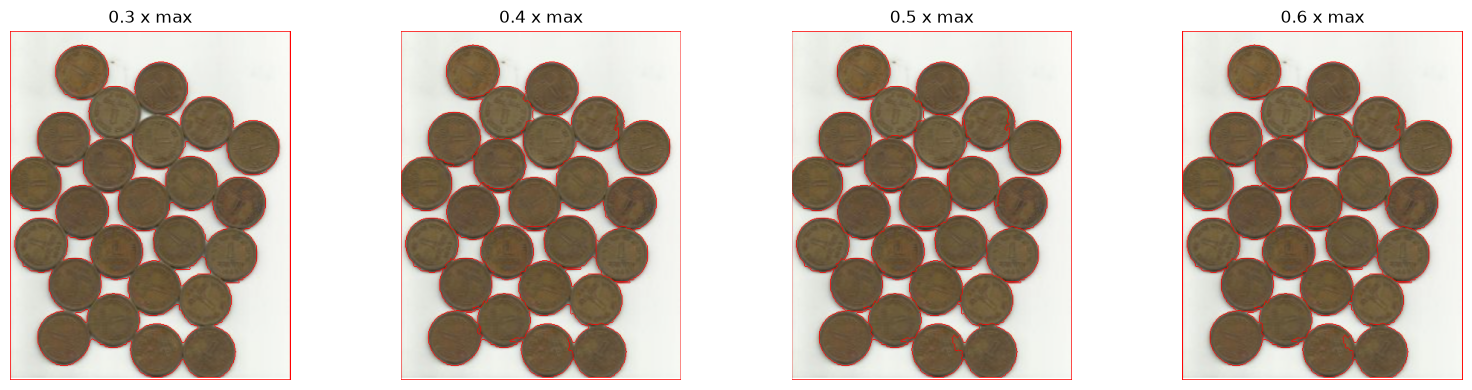

True

In [3]:
# Apply Gaussian blur to reduce noise
blur = cv2.GaussianBlur(
    gray,
    (5, 5),
    0
)

# Apply Otsu's thresholding with binary inversion
_, th = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Create a 3x3 kernel for morphological operations
k = np.ones(
    (3, 3),
    np.uint8
)

# Remove small noise using morphological opening
opening = cv2.morphologyEx(
    th,
    cv2.MORPH_OPEN,
    k,
    iterations=2
)

# Dilate the image to obtain the sure background
bg = cv2.dilate(
    opening,
    k,
    iterations=3
)

# Calculate the distance transform
dist = cv2.distanceTransform(
    opening,
    cv2.DIST_L2,
    5
)


# ---------------------------------------------------------
# Experiment with different distance threshold fractions
# ---------------------------------------------------------

# Different fractions of the maximum distance
fractions = [0.3, 0.4, 0.5, 0.6]

# Store experiment results and visualization images
rows = []
images = []

# Test each distance threshold
for f in fractions:

    # Create the sure foreground using the current fraction
    _, fg = cv2.threshold(
        dist,
        f * dist.max(),
        255,
        0
    )

    # Convert the foreground mask to 8-bit format
    fg = np.uint8(fg)

    # Find the unknown region
    unknown = cv2.subtract(
        bg,
        fg
    )

    # Find connected components in the foreground
    n, m = cv2.connectedComponents(fg)

    # Number of foreground markers
    foreground = n - 1

    # Shift marker labels so the background is not zero
    m = m + 1

    # Mark the unknown region as zero
    m[unknown == 255] = 0

    # Apply the Watershed algorithm
    m = cv2.watershed(
        bgr.copy(),
        m
    )

    # Count the separated regions
    separated = len([
        value
        for value in np.unique(m)
        if value > 1
    ])

    # Create a visualization of the watershed boundaries
    vis = rgb.copy()
    vis[m == -1] = [255, 0, 0]

    # Store the visualization and experiment results
    images.append(vis)
    rows.append(
        (f, foreground, separated)
    )


# ---------------------------------------------------------
# Print experiment results
# ---------------------------------------------------------

print(
    "Experiment | Distance threshold | "
    "Foreground markers | Separated regions"
)

for i, row in enumerate(rows, 1):
    print(
        i,
        "|",
        *row,
        sep=" | "
    )


# ---------------------------------------------------------
# Display results for all threshold values
# ---------------------------------------------------------

fig, ax = plt.subplots(
    1,
    4,
    figsize=(16, 4)
)

# Display the watershed result for each fraction
for a, f, image in zip(
    ax,
    fractions,
    images
):
    a.imshow(image)
    a.set_title(f"{f:.1f} x max")
    a.axis("off")

# Adjust spacing and display the results
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Save the result using the 0.5 threshold fraction
# ---------------------------------------------------------

cv2.imwrite(
    str(OUT / "task8_final.png"),
    cv2.cvtColor(
        images[2],
        cv2.COLOR_RGB2BGR
    )
)


## Analysis
Smaller distance fractions accept more pixels as sure foreground; larger fractions shrink foreground cores and may remove valid markers. Use the printed marker/region counts together with the four visual results to identify the meaningful range. A useful setting should give stable object cores without obvious merged or missing coins.